# Assignment 1
Analyze Canadian health & income data. \
Dataset: `Canadian_Health_Survey_Sample.csv`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Part A – Understanding the Data

### A1) Load CSV

In [ ]:
# df = pd.read_csv('../assets/Canadian_Health_Survey_Sample.csv')
df = pd.read_csv('https://raw.githubusercontent.com/TheChroniclerr/CP321/main/a1/assets/Canadian_Health_Survey_Sample.csv')

### A2) Information

In [11]:
df.head()

,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel
0,Ontario,female,59,80572.0,25.7,3.8,yes,Good,6.0
1,New Brunswick,Male,38,125739.0,24.2,3.4,No,Good,9.0
2,Nova Scotia,M,31,55997.0,35.7,NaN,No,Excellent,NaN
3,Saskatchewan,Male,30,75947.0,28.3,3.9,No,Excellent,10.0
4,Saskatchewan,female,79,113966.0,31.2,1.6,No,Fair,6.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Province          850 non-null    object 
 1   Gender            850 non-null    object 
 2   Age               850 non-null    int64  
 3   Income            816 non-null    float64
 4   BMI               808 non-null    float64
 5   PhysicalActivity  825 non-null    float64
 6   Smoking           850 non-null    object 
 7   SelfRatedHealth   850 non-null    object 
 8   StressLevel       825 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 59.9+ KB


In [5]:
df.describe(include='all')

,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel
count,850,850,850.000000,816.000000,808.000000,825.000000,850,850,825.000000
unique,10,6,NaN,NaN,NaN,NaN,6,5,NaN
top,Quebec,Male,NaN,NaN,NaN,NaN,No,Good,NaN
freq,100,230,NaN,NaN,NaN,NaN,552,258,NaN
mean,NaN,NaN,49.517647,77461.917892,27.488861,3.511394,NaN,NaN,5.294545
std,NaN,NaN,18.192604,22497.833440,5.064344,1.925825,NaN,NaN,2.121156
min,NaN,NaN,18.000000,5000.000000,13.500000,0.000000,NaN,NaN,1.000000
25%,NaN,NaN,33.000000,63438.000000,24.000000,2.100000,NaN,NaN,4.000000
50%,NaN,NaN,49.000000,78130.000000,27.300000,3.500000,NaN,NaN,5.000000
75%,NaN,NaN,66.000000,90529.500000,30.900000,4.700000,NaN,NaN,7.000000


### A3) Attributes
**Quantitative Attribute:** Age - Numerical and ordered.\
Age is just a number. Age is ordered as it has a size to it, 15 years old is younger than 20 years old.\
**Qualitative Attribute:** Province - Categorical and unordered.\
Province is a string category. Province does not have a size, it does not make sense to say one pronvicne is greater than another.

## Part B – Cleaning & Structuring

### B1) Normalization
Standardize naming for values.

In [6]:
# Check all existing values for genders
df["Gender"].unique()

array(['female', 'Male', 'M', 'F', 'Female', 'male'], dtype=object)

In [7]:
# Normalize
gender_map = {
    "male": "Male",
    "m": "Male",
    "female": "Female",
    "f": "Female"
}

df["Gender"] = df["Gender"].str.lower().map(gender_map)

df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [8]:
# Check all existing values for smoking
df["Smoking"].unique()

array(['yes', 'No', 'Y', 'Yes', 'N', 'no'], dtype=object)

In [9]:
# Normalize
smoking_map = {
    "yes": "Yes",
    "y": "Yes",
    "no": "No",
    "n": "No"
}

df["Smoking"] = df["Smoking"].str.lower().map(smoking_map)

df["Smoking"].unique()

array(['Yes', 'No'], dtype=object)

### B2) Dropna / Imputation
Remove or replace 'nan' values.
<table border="1" cellpadding="5" cellspacing="0">
  <thead>
    <tr>
      <th>Variable</th>
      <th>Approach</th>
      <th>Reason</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>BMI</td>
      <td>Median imputation</td>
      <td>BMI is continuous and can have outliers → median is robust.</td>
    </tr>
    <tr>
      <td>Income</td>
      <td>Median imputation</td>
      <td>Income is usually skewed → median better than mean.</td>
    </tr>
    <tr>
      <td>StressLevel</td>
      <td>Median imputation</td>
      <td>Ordinal numeric (1–10), no huge skew, median is safe.</td>
    </tr>
    <tr>
      <td>PhysicalActivity</td>
      <td>Median imputation</td>
      <td>Depends on % missing, if few rows missing, median is fine.</td>
    </tr>
  </tbody>
</table>

In [10]:
# Check nan counts per column
df[["BMI", "Income", "StressLevel", "PhysicalActivity"]].isna().sum()

BMI                 42
Income              34
StressLevel         25
PhysicalActivity    25
dtype: int64

In [11]:
# Handle nan values
df["BMI"] = df["BMI"].fillna(df["BMI"].median())
df["Income"] = df["Income"].fillna(df["Income"].median())
df["StressLevel"] = df["StressLevel"].fillna(df["StressLevel"].median())
df["PhysicalActivity"] = df["PhysicalActivity"].fillna(df["PhysicalActivity"].median())

df[["BMI", "Income", "StressLevel", "PhysicalActivity"]].isna().sum()

BMI                 0
Income              0
StressLevel         0
PhysicalActivity    0
dtype: int64

### B3) Data Typing
Cast values to preferred data type.

In [12]:
# Check exiting data types
df.dtypes

Province             object
Gender               object
Age                   int64
Income              float64
BMI                 float64
PhysicalActivity    float64
Smoking              object
SelfRatedHealth      object
StressLevel         float64
dtype: object

In [13]:
# Enforce data types
df["Age"] = df["Age"].astype(int)
df["Income"] = df["Income"].astype(float)
df["BMI"] = df["BMI"].astype(float)
df["StressLevel"] = df["StressLevel"].astype(int)

df.dtypes

Province             object
Gender               object
Age                   int64
Income              float64
BMI                 float64
PhysicalActivity    float64
Smoking              object
SelfRatedHealth      object
StressLevel           int64
dtype: object

### B4) Derivation
Get derived values from exisitng data.
<table border="1" cellpadding="5" cellspacing="0">
  <thead>
    <tr>
      <th>BMI Category</th>
      <th>BMI Range</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Underweight</td>
      <td>&lt; 18.5</td>
    </tr>
    <tr>
      <td>Normal</td>
      <td>18.5–24.9</td>
    </tr>
    <tr>
      <td>Overweight</td>
      <td>25–29.9</td>
    </tr>
    <tr>
      <td>Obese</td>
      <td>&ge; 30</td>
    </tr>
  </tbody>
</table>


In [14]:
# Create derived columns
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, float('inf')],
    labels=["Underweight", "Normal", "Overweight", "Obese"],
    right=False
)

df["IncomeBracket"] = pd.cut(
    df["Income"],
    bins=[0, 50000, 80000, 110000, float('inf')],
    labels=["<50k", "50-80k", "80-110k", ">110k"],
    right=False
)

df_cleaned = df.copy(deep=True)

df[["BMI", "BMI_Category", "Income", "IncomeBracket"]].head()

,BMI,BMI_Category,Income,IncomeBracket
0,25.7,Overweight,80572.0,80-110k
1,24.2,Normal,125739.0,>110k
2,35.7,Obese,55997.0,50-80k
3,28.3,Overweight,75947.0,50-80k
4,31.2,Obese,113966.0,>110k


## Part C – Visualization

### C1) Bar Chart

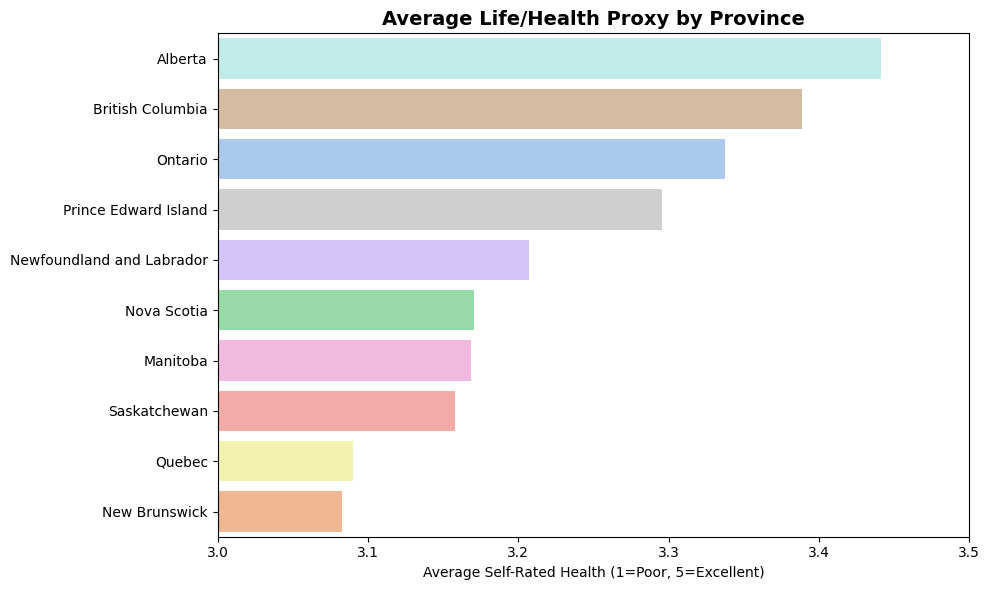

In [15]:
# Bar chart
health_map = {
    "Poor": 1,
    "Fair": 2,
    "Good": 3,
    "Very Good": 4,
    "Excellent": 5
}

df["SelfRatedHealthNumber"] = df["SelfRatedHealth"].map(health_map)
order = df.groupby("Province")["SelfRatedHealthNumber"].mean().sort_values(ascending=False).index

plt.figure(figsize=(10,6))
sns.barplot(
    data=df, 
    x="SelfRatedHealthNumber", 
    y="Province", 
    order=order, 
    orient="h", 
    errorbar=None, 
    hue="Province", 
    palette="pastel"
)

plt.title("Average Life/Health Proxy by Province", fontsize=14, fontweight='bold')
plt.xlabel("Average Self-Rated Health (1=Poor, 5=Excellent)")
plt.ylabel("")

plt.xlim(3, 3.5)            # zoom y-axis to focus between 3.0 to 3.5 where all values lie
plt.tight_layout()
plt.show()

### C2) Scatterplot

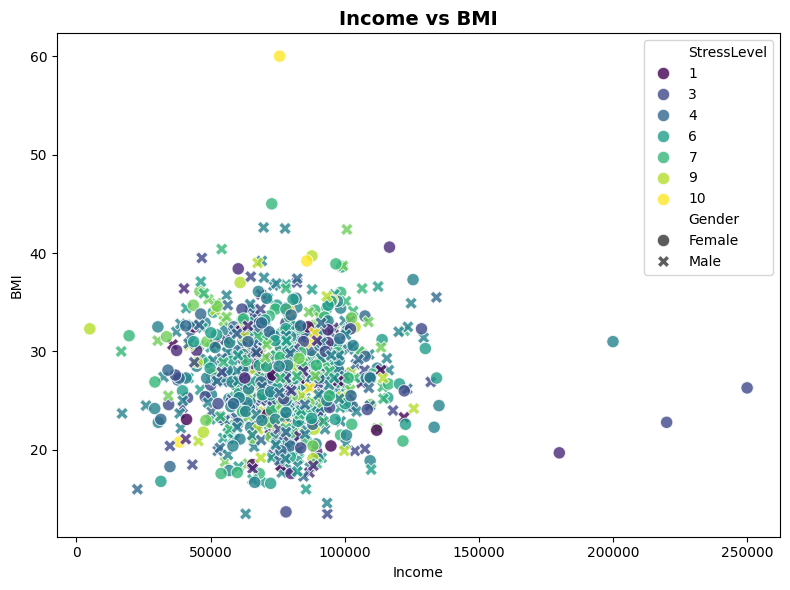

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, 
    x="Income", 
    y="BMI", 
    style="Gender", 
    hue="StressLevel", 
    palette="viridis", 
    s=80, 
    alpha=0.8
)

plt.title("Income vs BMI", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### C3) Diverging Visualization

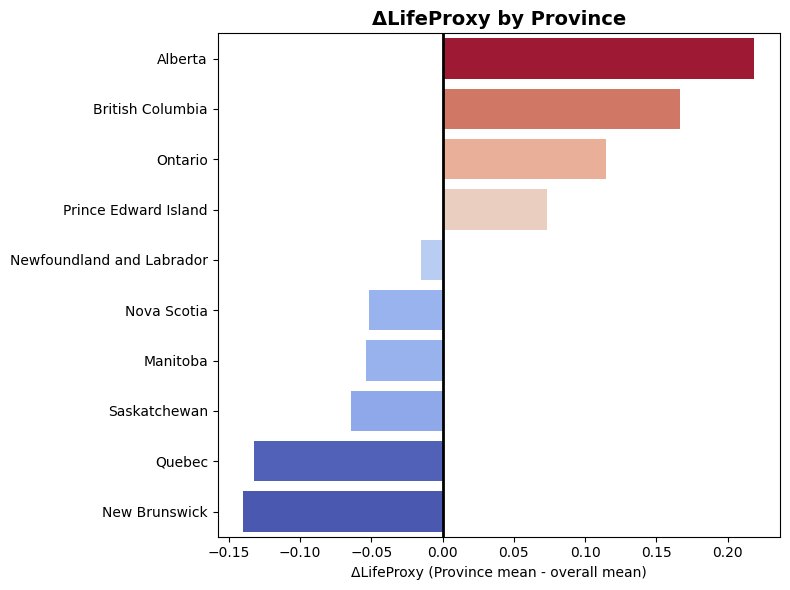

In [17]:
overall_mean = df["SelfRatedHealthNumber"].mean()
delta_life = df.groupby("Province")["SelfRatedHealthNumber"].mean() - overall_mean
# df["ΔLifeProxy"] = df.groupby("Province")["SelfRatedHealthNumber"].transform("mean") - overall_mean       # not useful, but interesting

plt.figure(figsize=(8,6))
sns.barplot(
    x=delta_life.values,
    y=delta_life.index,
    order=delta_life.sort_values(ascending=False).index, 
    orient="h",
    hue=delta_life.values,
    palette="coolwarm",
    legend=False
)

plt.title("ΔLifeProxy by Province", fontsize=14, fontweight='bold')
plt.xlabel("ΔLifeProxy (Province mean - overall mean)")
plt.ylabel("")

plt.axvline(0, color="black", linewidth=2)
plt.tight_layout()
plt.show()

### C4) Design Choices
1. **Types of data**
- Quantitative/numerical continuous: C1 average self-rated health, C2 BMI, income
- Quantitative/numerical discrete: C2 stress level, C3 delta life proxy (by province)
- Qualitative/categorical unordered: C1 provinces, C2 genders, C3 provinces
1. **Color Scale**
- Colors - different color to represent categorical data. E.g. the colors in the bar chart in C1 are used to represent different provinces.
- Hues - a saturation gradient to represent numerical data. E.g. the blue to red hue in C3 is used to represent the negative to positive delta life proxy.
2. **Shapes**
- different shapes to represent categorical data E.g. different shapes are used along side color in C2 to represent male and female.
3. **Cognitive Load Theory (CLT)**
- Redundancy - no labels or other data are repeated in the charts.
- Coherence - no unnecessary information are presented in the charts.
- Signaling - the title of the charts are bold cased.
4. **Others**
- Descending Orders - uses descending order of values for unordered indexes. 
- Horizontal Bars - prevent overlapping index values.
- Remove Obvious Labels - e.g. Province

## Part D – Interpretation
### D1) Discusssion
**C1)**: The chart provide statistical data for how citizen of each Canadian province rate their own health. It does not suggest any explanation as to why the differences exist. Using this chart, we can infer that Western provinces (e.g., Alberta, British Columbia, Ontario) report higher average health, while Atlantic provinces and Quebec tend to report lower averages.\
**C2)**: This chart displays no strong linear relationship between income and BMI. It does show a central clustering around income of ~$40,000–$100,000 and BMI of ~20–35. The chart provides no significant trend for stress leve and gender differences.\
**C3)**: The chart compares values in C1) with the overall mean, showing Alberta, British Columbia, and Ontario have the largest positive deviations above the national average. Additonally, this chart shows French speaking regions have much lower average health proxy than the rest. 
### D2) Limitations
**C1&C3)**: The chart does not present any correlation due to provinces being an unordered data. By presenting additional data via color coding (like C2) or other means, it can provide an explanation to why differences between provinces exist.\
**C2)**: The dataset is skewed toward average income and BMI values, while higher and lower income and BMI groups are underrepresented. As a result, this dataset reflects the distribution of the general population more so than the correlation between the variables. A more balanced sample would improve the analysis. In addition, the color and shape coding failed to present data effectively. A better approach is to seperate those categories into its own graphs for a much more effective representation of the data.

# Submission
## Export

In [19]:
# Export cleaned CSV
df_cleaned.to_csv("../outputs/cleaned.csv", index=False)
df_cleaned

,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel,BMI_Category,IncomeBracket
0,Ontario,Female,59,80572.0,25.7,3.8,Yes,Good,6,Overweight,80-110k
1,New Brunswick,Male,38,125739.0,24.2,3.4,No,Good,9,Normal,>110k
2,Nova Scotia,Male,31,55997.0,35.7,3.5,No,Excellent,5,Obese,50-80k
3,Saskatchewan,Male,30,75947.0,28.3,3.9,No,Excellent,10,Overweight,50-80k
4,Saskatchewan,Female,79,113966.0,31.2,1.6,No,Fair,6,Obese,>110k
...,...,...,...,...,...,...,...,...,...,...,...
845,Ontario,Female,68,102355.0,25.5,6.3,No,Fair,4,Overweight,80-110k
846,Quebec,Female,46,78130.0,13.7,3.0,Yes,Poor,3,Underweight,50-80k
847,Ontario,Female,78,108434.0,24.1,3.5,Yes,Good,3,Normal,80-110k
848,Newfoundland and Labrador,Male,18,85176.0,24.6,5.3,No,Very Good,4,Normal,80-110k
